In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Visualization

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import Planck18
from astropy.io import ascii
import random
from astropy.coordinates import SkyCoord
from astropy import units as u

In [4]:
data_n = Table.read("https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/LSS/iron/LSScats/v1.5/LRG_NGC_clustering.dat.fits")
data_s = Table.read("https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/LSS/iron/LSScats/v1.5/LRG_SGC_clustering.dat.fits")

In [5]:
def cartesianas(data):
    data['distance'] = Planck18.comoving_distance(data['Z'])
    coords = SkyCoord(ra=data['RA'], dec=data['DEC'], distance=data['distance'], frame='icrs')
    data['x'] = coords.cartesian.x.value
    data['y'] = coords.cartesian.y.value
    data['z'] = coords.cartesian.z.value

    data['x'] = data['x'] * u.Mpc
    data['y'] = data['y'] * u.Mpc
    data['z'] = data['z'] * u.Mpc

In [6]:
cartesianas(data_n)
cartesianas(data_s)

data_n = data_n[['TARGETID', 'Z', 'RA', 'DEC','x','y','z']]
data_s= data_s[['TARGETID', 'Z', 'RA', 'DEC','x','y','z']]

data_n['type'] = 'data'
data_s['type'] = 'data'

filename_data_n = f"/content/drive/MyDrive/DESI/data/LRG_NGC_data.ecsv"
filename_data_s = f"/content/drive/MyDrive/DESI/data/LRG_SGC_data.ecsv"

ascii.write(data_n, filename_data_n, format='ecsv', overwrite=True)
ascii.write(data_s, filename_data_s, format='ecsv', overwrite=True)

data_n = data_n.to_pandas()
data_s = data_s.to_pandas()

In [7]:
def max_value(data):

    n, bins, patches = plt.hist(data['Z'],bins=10,color='#30C4C9')
    pos_max_bin = np.argmax(n)
    bin_center = (bins[pos_max_bin] + bins[pos_max_bin+1]) / 2
    left = bin_center - 0.003
    right = bin_center + 0.003

    return (left, right)

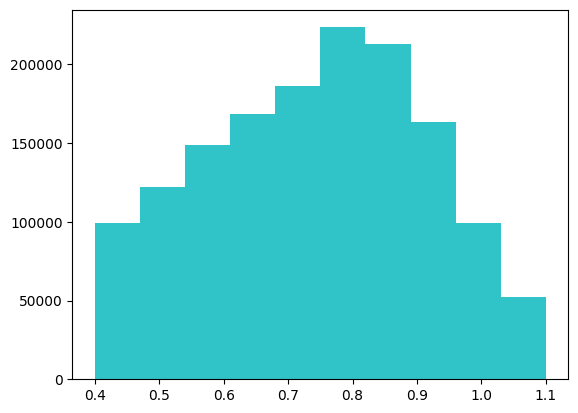

In [8]:
max_value_n = max_value(data_n)
max_value_s = max_value(data_s)

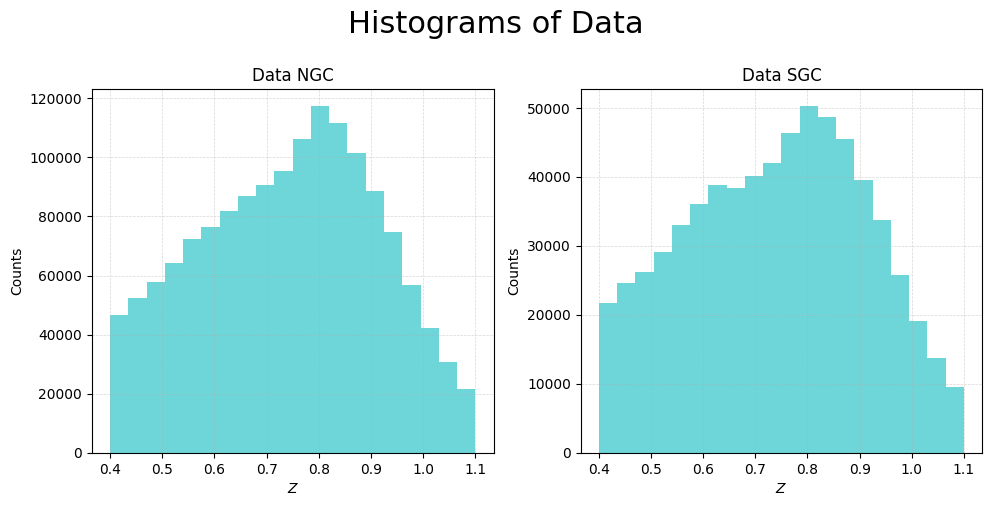

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data_dict = {'n': data_n, 's': data_s}
titles = {'n': 'Data NGC', 's': 'Data SGC'}

orientations = ['n', 's']

for idx, ori in enumerate(orientations):
    ax = axes[idx]
    data = data_dict[ori]

    # Histograma
    ax.hist(data['Z'], bins=20, color='#30C4C9', alpha=0.7)

    # Etiquetas y título
    ax.set_xlabel(r'$Z$')
    ax.set_ylabel('Counts')
    ax.set_title(titles[ori])
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Histograms of Data', fontsize=22, y=1)

plt.tight_layout(pad=1.0)
plt.show()

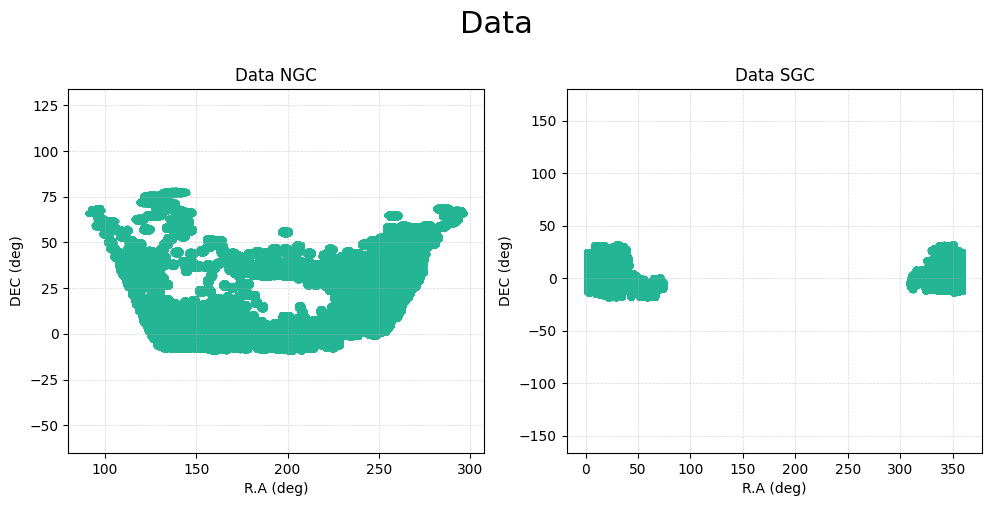

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data_dict = {'n': data_n, 's': data_s}
max_values = {'n': max_value_n, 's': max_value_s}
titles = {'n': 'Data NGC', 's': 'Data SGC'}

orientations = ['n', 's']

for idx, ori in enumerate(orientations):
    ax = axes[idx]
    data = data_dict[ori]

    ax.scatter(data['RA'], data['DEC'], s=5, c='#24B694')

    ax.set_xlabel('R.A (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(titles[ori])
    ax.axis('equal')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Data', fontsize=22, y=1)

plt.tight_layout(pad=1.0)
plt.show()

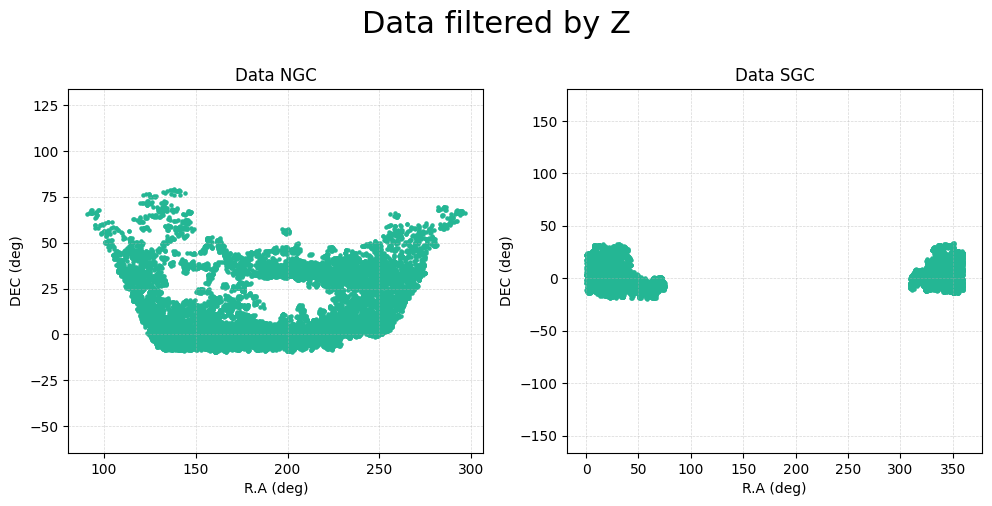

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data_dict = {'n': data_n, 's': data_s}
max_values = {'n': max_value_n, 's': max_value_s}
titles = {'n': 'Data NGC', 's': 'Data SGC'}

orientations = ['n', 's']

for idx, ori in enumerate(orientations):
    ax = axes[idx]
    data = data_dict[ori]
    min_z, max_z = max_values[ori]

    bounds = (data['Z'] > min_z) & (data['Z'] < max_z)
    ax.scatter(data['RA'][bounds], data['DEC'][bounds], s=5, c='#24B694')

    ax.set_xlabel('R.A (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(titles[ori])
    ax.axis('equal')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Data filtered by Z', fontsize=22, y=1)

plt.tight_layout(pad=1.0)
plt.show()

In [12]:
%%time
rand_n = Table.read('https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/LSS/iron/LSScats/v1.5/LRG_NGC_0_clustering.ran.fits')

CPU times: user 5.55 s, sys: 4.31 s, total: 9.86 s
Wall time: 50.2 s


In [13]:
%%time
rand_s = Table.read('https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/LSS/iron/LSScats/v1.5/LRG_SGC_0_clustering.ran.fits')

CPU times: user 2.62 s, sys: 1.59 s, total: 4.21 s
Wall time: 25.1 s


In [14]:
cartesianas(rand_n)
cartesianas(rand_s)

In [15]:
rand_n = rand_n.to_pandas()[['TARGETID', 'Z', 'RA', 'DEC','x','y','z']]
rand_s = rand_s.to_pandas()[['TARGETID', 'Z', 'RA', 'DEC','x','y','z']]

In [16]:
def d(data):
    data['d'] = np.sqrt((data['x']*data['x'])+(data['y']*data['y'])+(data['z']*data['z']))

In [17]:
d(data_n)
d(data_s)
d(rand_n)
d(rand_s)

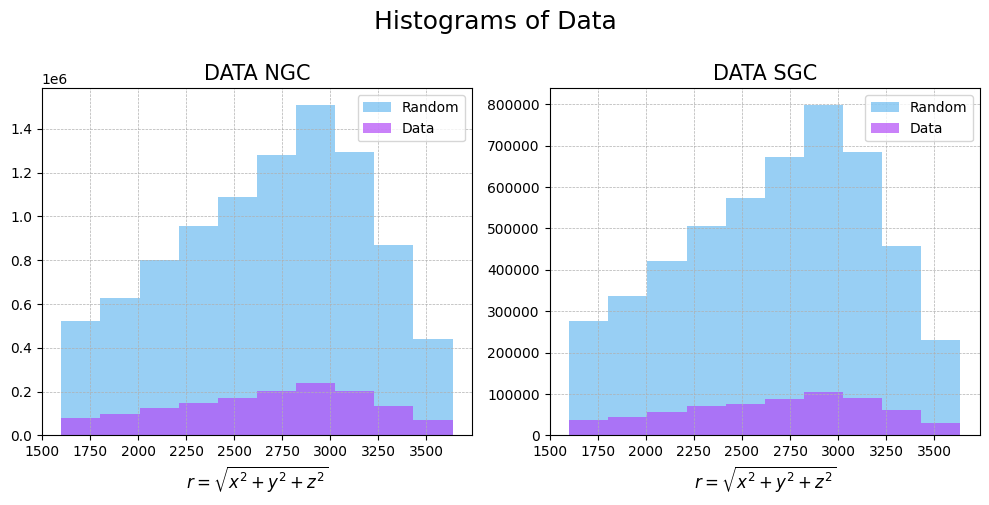

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
orientations = ['n', 's']

data_dict = {'n': data_n, 's': data_s}
rand_dict = {'n': rand_n, 's': rand_s}

for idx, ori in enumerate(orientations):
    ax = axes[idx]

    ax.hist(rand_dict[ori]['d'], bins=10, color='#32A1EA', alpha=0.5, label='Random')
    ax.hist(data_dict[ori]['d'], bins=10, color='#b34cf7', alpha=0.7, label='Data')

    ax.set_title(f'DATA {ori.upper()}GC', size=15)
    ax.set_xlabel(r'$r = \sqrt{x^{2} + y^{2} + z^{2}}$', size=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()

fig.suptitle('Histograms of Data', fontsize=18, y=1)
plt.tight_layout()
plt.show()

# Data filtered

In [19]:
mask_n = (data_n['RA'] >= 150) & (data_n['RA'] <= 210) & (data_n['DEC'] >= -8) & (data_n['DEC'] <= 8)
filt_n = data_n[mask_n]

mask_s = (data_s['RA'] >= 0) & (data_s['RA'] <= 100) & (data_s['DEC'] >= -50) & (data_s['DEC'] <= 50)
filt_s = data_s[mask_s]

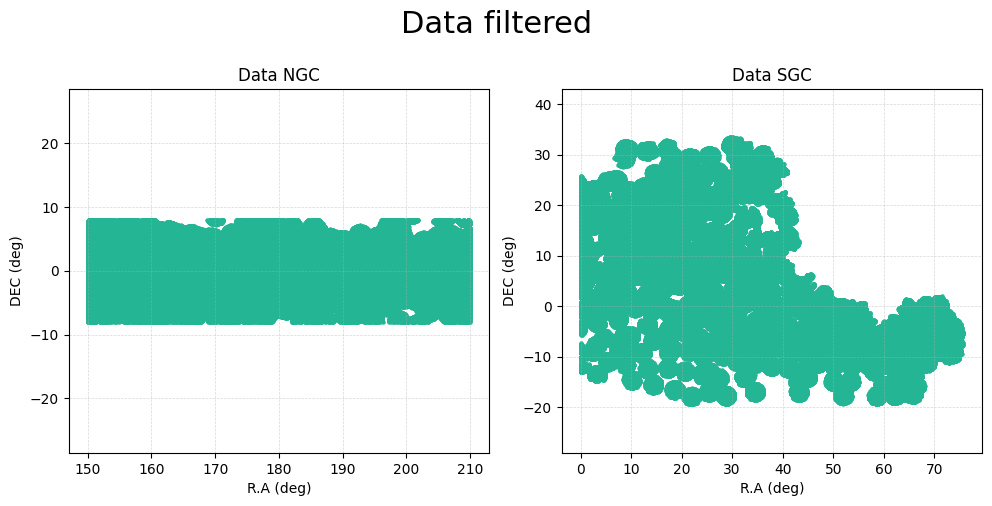

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data_dict = {'n': filt_n, 's': filt_s}
titles = {'n': 'Data NGC', 's': 'Data SGC'}

orientations = ['n', 's']

for idx, ori in enumerate(orientations):
    ax = axes[idx]
    data = data_dict[ori]

    ax.scatter(data['RA'], data['DEC'], s=5, c='#24B694')

    ax.set_xlabel('R.A (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(titles[ori])
    ax.axis('equal')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Data filtered', fontsize=22, y=1)

plt.tight_layout(pad=1.0)
plt.show()

## Data filtered NGC-1 y NGC-2

In [21]:
mask_n1 = (data_n['RA'] >= 110) & (data_n['RA'] <= 260) & (data_n['DEC'] >= -10) & (data_n['DEC'] <= 8)
filt_n1 = data_n[mask_n1]

mask_n2 = (data_n['RA'] >= 180) & (data_n['RA'] <= 260) & (data_n['DEC'] >= 30) & (data_n['DEC'] <= 40)
filt_n2 = data_n[mask_n2]

filt_n1['type'] = 'data'
filt_n2['type'] = 'data'

/tmp/ipython-input-21-551291551.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt_n1['type'] = 'data'
/tmp/ipython-input-21-551291551.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt_n2['type'] = 'data'


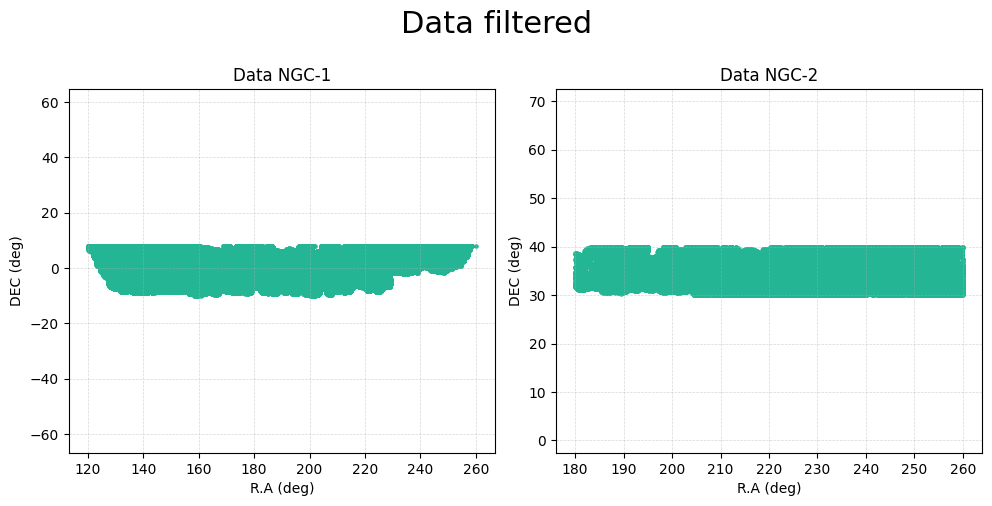

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
data_dict = (filt_n1, filt_n2)
titles = ('Data NGC-1', 'Data NGC-2')

for i in range(2):
    ax = axes[i]
    data = data_dict[i]

    ax.scatter(data['RA'], data['DEC'], s=5, c='#24B694')
    ax.set_xlabel('R.A (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(titles[i])
    ax.axis('equal')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Data filtered', fontsize=22, y=1)
plt.tight_layout(pad=1.0)
plt.show()


In [23]:
filt_n1 = filt_n1[['TARGETID','x','y','z','type']]
filt_n2 = filt_n2[['TARGETID','x','y','z','type']]

filt_n1 = Table.from_pandas(filt_n1)
filt_n2 = Table.from_pandas(filt_n2)

filename_data_n1 = f"/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv"
filename_data_n2 = f"/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt2.ecsv"

ascii.write(filt_n1, filename_data_n1, format='ecsv', overwrite=True)
ascii.write(filt_n2, filename_data_n2, format='ecsv', overwrite=True)